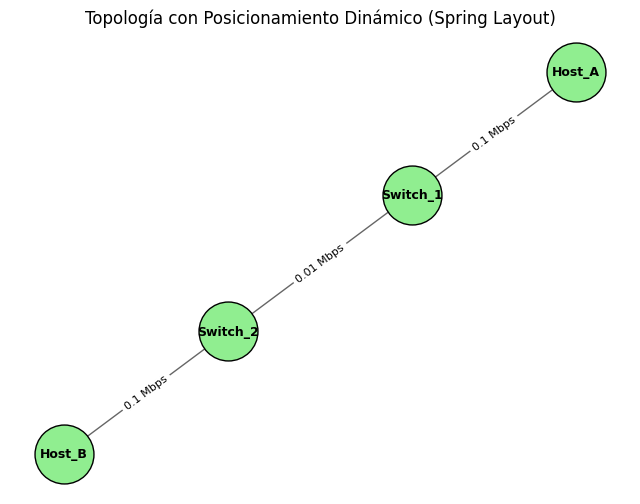

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import re

# 1. Función para parsear el archivo graph.txt
def parse_graph_txt(file_path):
    with open(file_path, 'r') as f:
        content = f.read()
    nodes = re.findall(r'node \[\s+id (\d+)\s+label "([^"]+)"', content)
    edges = re.findall(r'edge \[\s+source (\d+)\s+target (\d+).*?bandwidth "(\d+)"', content, re.DOTALL)
    return nodes, edges

# 2. Cargar datos
nodes_data, edges_data = parse_graph_txt('graph.txt')

# 3. Crear el grafo
G = nx.Graph()
for node_id, label in nodes_data:
    G.add_node(int(node_id), label=label)

for src, dst, bw in edges_data:
    if not G.has_edge(int(src), int(dst)):
        G.add_edge(int(src), int(dst), bandwidth=int(bw))

pos = nx.spring_layout(G) 

# 5. Configuración de la visualización
plt.figure(figsize=(8, 6))

# Dibujar nodos
node_labels = nx.get_node_attributes(G, 'label')
nx.draw_networkx_nodes(G, pos, node_size=1800, node_color='lightgreen', edgecolors='black')
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9, font_weight='bold')

# Dibujar aristas resaltando el cuello de botella (10,000 bps)
edges_list = list(G.edges())
nx.draw_networkx_edges(G, pos, alpha=0.6)

# Añadir etiquetas de ancho de banda
edge_labels = {(u, v): f"{G[u][v]['bandwidth']/1e6} Mbps" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
1
plt.title("Topología")
plt.axis('off')
plt.show()

/tmp/ipykernel_584047/1831774662.py:73: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red',
/tmp/ipykernel_584047/1831774662.py:73: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red',
/tmp/ipykernel_584047/1831774662.py:73: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True`

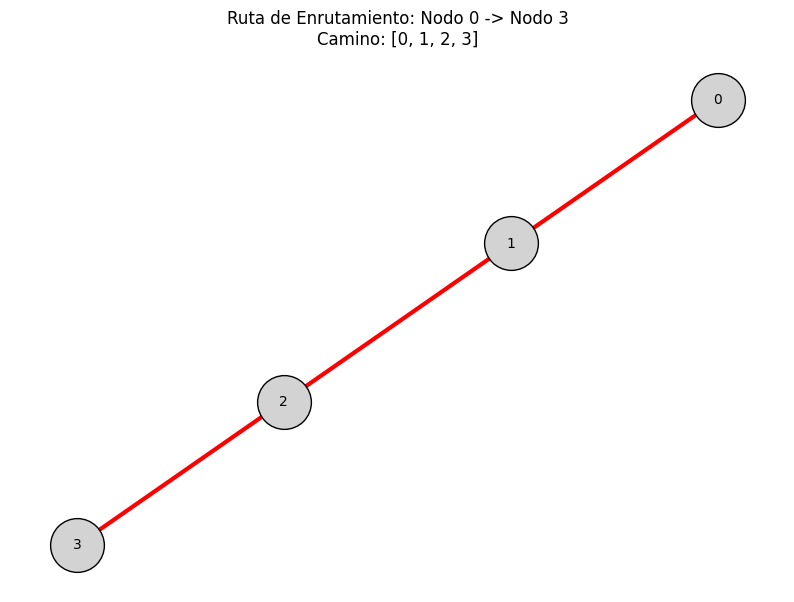

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
import re
import numpy as np

# 1. Función para parsear graph.txt (incluyendo puertos)
def parse_graph_txt(file_path):
    with open(file_path, 'r') as f:
        content = f.read()
    nodes = re.findall(r'node \[\s+id (\d+)\s+label "([^"]+)"', content)
    # Buscamos source, target, port y bandwidth
    edges = re.findall(r'edge \[\s+source (\d+)\s+target (\d+)\s+key \d+\s+port (\d+).*?bandwidth "(\d+)"', content, re.DOTALL)
    return nodes, edges

# 2. Función para parsear routing.txt
def parse_routing_txt(file_path):
    matrix = []
    with open(file_path, 'r') as f:
        for line in f:
            # Limpiar posibles etiquetas como "" y extraer números
            clean_line = re.sub(r'\[.*?\]', '', line).strip()
            if clean_line:
                row = [int(x) for x in clean_line.split(',')]
                matrix.append(row)
    return np.array(matrix)

# 3. Cargar datos
nodes_data, edges_data = parse_graph_txt('graph.txt')
routing_matrix = parse_routing_txt('routing.txt')

# 4. Construir el Grafo y el mapa de puertos
G = nx.Graph()
port_map = {} # (nodo_origen, puerto) -> nodo_destino

for node_id, label in nodes_data:
    G.add_node(int(node_id), label=label)

for src, dst, port, bw in edges_data:
    u, v, p = int(src), int(dst), int(port)
    if not G.has_edge(u, v):
        G.add_edge(u, v, bandwidth=int(bw))
    port_map[(u, p)] = v

# 5. Función para calcular el camino basado en la matriz
def get_routing_path(src, dst, matrix, p_map):
    path = [src]
    curr = src
    visited = {src} # Evitar bucles infinitos
    while curr != dst:
        port = matrix[curr][dst]
        if port == -1: break
        next_node = p_map.get((curr, port))
        if next_node is None or next_node in visited: break
        path.append(next_node)
        visited.add(next_node)
        curr = next_node
    return path

# --- VISUALIZACIÓN ---
src_node, dst_node = 0, 3 # Ejemplo: Camino del Host_A al Host_B
route = get_routing_path(src_node, dst_node, routing_matrix, port_map)

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10, 7))

# Dibujar Topología Base (Gris claro)
nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='lightgray', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray', width=1)

# Dibujar el CAMINO DE ROUTING (Flechas rojas)
path_edges = list(zip(route, route[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', 
                       width=3, arrowstyle='->', arrowsize=20, 
                       connectionstyle='arc3,rad=0.1') # rad=0.1 para que no se solape

# Etiquetas
plt.title(f"Ruta de Enrutamiento: Nodo {src_node} -> Nodo {dst_node}\nCamino: {route}")
plt.axis('off')
plt.show()